# BAW Notebook 00a: Multi-Structure SASA Analysis

**Purpose:** Build a consensus solvent accessibility profile for a target protein
by aligning multiple PDB structures to the canonical UniProt sequence and
averaging SASA values across all structures.

**Why this matters:** A single crystal structure gives a SASA snapshot of one
conformation. Residues that appear buried in one structure (e.g. Tyr119 and
Trp312 in 1S0I which are occluded by the substrate) may be genuinely accessible
in other conformations. Multi-structure averaging gives a reliable picture of
which residues are accessible across the conformational ensemble.

**Input:**
- UniProt accession number (fetched automatically from UniProt REST API)
- Two or more PDB files of the same protein (different conformations, mutants,
  ligand states)

**Output:**
- `{target_label}_consensus_sasa.json` — per-residue consensus SASA profile
  in canonical UniProt numbering, ready for Notebook 01

**Notebook 01 integration:** Notebook 01 automatically loads this file if it
exists in the data directory and uses the consensus SASA instead of
single-structure SASA for candidate pool selection.


In [1]:
# Cell 1: Imports

import os
import sys
import json
import subprocess
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from Bio.PDB import PDBParser, PPBuilder
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# --------------------------------------------------------------------------
# Shared plotting palette -- kept consistent with Notebook 01
# --------------------------------------------------------------------------
CATEGORY_COLORS = {
    'catalytic':   '#C0392B',   # deep red
    'hydrophobic': '#E67E22',   # orange
    'surface':     '#2980B9',   # blue
    'polar':       '#27AE60',   # green
    'unknown':     '#95A5A6',   # grey
}
SASA_COLORMAP = 'RdYlGn'  # red=buried, green=exposed
CATEGORY_SASA = {
    'A_consistently_exposed': '#2ECC71',
    'B_mostly_exposed':       '#F39C12',
    'C_variable':             '#E74C3C',
    'D_mostly_buried':        '#95A5A6',
    'missing':                '#BDC3C7',
}

# ── PowerShell popup helpers ────────────────────────────────────────────────
def ps_browse_files_multi(title="Select PDB files"):
    """Open a Windows multi-select file dialog via PowerShell."""
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.OpenFileDialog
$d.Title = "{title}"
$d.Filter = "PDB files|*.pdb|All files|*.*"
$d.Multiselect = $true
$d.ShowDialog() | Out-Null
$d.FileNames -join "|"
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    raw = r.stdout.strip()
    if not raw:
        return []
    paths = []
    for p in raw.split("|"):
        p = p.strip()
        if not p:
            continue
        w = subprocess.run(["wslpath", p], capture_output=True, text=True)
        wsl = w.stdout.strip()
        if wsl:
            paths.append(wsl)
    return paths

def ps_browse_folder(title="Select output folder"):
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.FolderBrowserDialog
$d.Description = "{title}"
$d.ShowNewFolderButton = $true
$d.ShowDialog() | Out-Null
Write-Output $d.SelectedPath
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    p = r.stdout.strip()
    if not p:
        return None
    w = subprocess.run(["wslpath", p], capture_output=True, text=True)
    return w.stdout.strip() or None

print("Imports loaded.")


Imports loaded.


In [2]:
# Cell 2: Configuration

W = dict(style={'description_width': '160px'})

target_name_w = widgets.Text(
    value='', description='Target name:',
    placeholder='e.g. Trans-sialidase',
    layout=widgets.Layout(width='400px'), **W)

target_label_w = widgets.Text(
    value='', description='File label:',
    placeholder='e.g. ts',
    layout=widgets.Layout(width='300px'), **W)

uniprot_w = widgets.Text(
    value='', description='UniProt accession:',
    placeholder='e.g. Q26966',
    layout=widgets.Layout(width='320px'), **W)

sasa_threshold_w = widgets.FloatSlider(
    value=0.15, min=0.05, max=0.50, step=0.01,
    description='SASA threshold:',
    readout_format='.2f',
    layout=widgets.Layout(width='420px'), **W)

confirm_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
conf_out = widgets.Output()

def on_confirm(_):
    global TARGET_NAME, TARGET_LABEL, UNIPROT_ACCESSION, SASA_THRESHOLD
    TARGET_NAME        = target_name_w.value.strip()
    TARGET_LABEL       = target_label_w.value.strip()
    UNIPROT_ACCESSION  = uniprot_w.value.strip()
    SASA_THRESHOLD     = sasa_threshold_w.value
    with conf_out:
        clear_output()
        print(f'Configuration confirmed.')
        print(f'  Target     : {TARGET_NAME}  (label: {TARGET_LABEL})')
        print(f'  UniProt    : {UNIPROT_ACCESSION}')
        print(f'  SASA threshold: {SASA_THRESHOLD}')

confirm_btn.on_click(on_confirm)

# Initialise with defaults
TARGET_NAME       = target_name_w.value
TARGET_LABEL      = target_label_w.value
UNIPROT_ACCESSION = uniprot_w.value
SASA_THRESHOLD    = sasa_threshold_w.value

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Configuration</h3>'),
    target_name_w, target_label_w, uniprot_w, sasa_threshold_w,
    widgets.HTML('<hr>'),
    widgets.HTML(
        '<i>Seed residues and sphere radius are defined in Cell 5b '
        'after structures are loaded.</i>'),
    confirm_btn, conf_out
]))


In [3]:
# Cell 3: Select output directory and PDB files

out = widgets.Output()
display(out)

# Output directory
with out:
    print('Select output directory...')
output_dir_str = ps_browse_folder('Select output directory for Notebook 00a results')
with out:
    if output_dir_str:
        output_dir = Path(output_dir_str)
    else:
        output_dir = Path.home() / 'BasementAntibodyWorks' / 'data' / TARGET_LABEL
        print(f'Using default: {output_dir}')
output_dir.mkdir(parents=True, exist_ok=True)
with out:
    print(f'Output dir: {output_dir}')

# PDB files — multi-select
with out:
    print()
    print('Select PDB files (hold Ctrl to select multiple)...')
pdb_paths = ps_browse_files_multi(
    title=f'Select PDB structures for {TARGET_NAME} (Ctrl = multi-select)')
with out:
    if not pdb_paths:
        raise FileNotFoundError('No PDB files selected. Re-run this cell.')
    print(f'Selected {len(pdb_paths)} structure(s):')
    for p in pdb_paths:
        print(f'  {Path(p).name}')


Output()

In [4]:
# Cell 4: Fetch canonical sequence from UniProt

print(f'Fetching canonical sequence for {UNIPROT_ACCESSION} from UniProt...')

url = f'https://rest.uniprot.org/uniprotkb/{UNIPROT_ACCESSION}.fasta'
response = requests.get(url, timeout=30)

if response.status_code != 200:
    raise ValueError(
        f'UniProt fetch failed (status {response.status_code}).\n'
        f'Check accession {UNIPROT_ACCESSION} at https://www.uniprot.org'
    )

fasta_lines = response.text.strip().split('\n')
uniprot_header = fasta_lines[0]
uniprot_seq = ''.join(fasta_lines[1:])

print(f'Header  : {uniprot_header[:80]}')
print(f'Length  : {len(uniprot_seq)} amino acids')
print(f'Sequence: {uniprot_seq[:60]}...')


Fetching canonical sequence for Q26966 from UniProt...
Header  : >tr|Q26966|Q26966_TRYCR Trans-sialidase OS=Trypanosoma cruzi OX=5693 PE=1 SV=1
Length  : 642 amino acids
Sequence: MLAPGSSRVELFKRQSSKVPFEKDGKVTERVVHSFRLPALVNVDGVMVAIADARYETSND...


In [5]:
# Cell 5: Load all PDB structures
#
# Extracts a sequence from chain 'A' by default (the common case), but this
# is not hardcoded — if a structure has no chain 'A' its first available
# chain is used instead. The full list of chains is kept per structure so
# Cell 5b can offer any chain as the reference chain.

parser = PDBParser(QUIET=True)
structures = {}

DEFAULT_CHAIN = 'A'

print(f'Loading {len(pdb_paths)} structure(s)...')
print()

for pdb_path in pdb_paths:
    stem = Path(pdb_path).stem.upper()
    if Path(pdb_path).stat().st_size < 1000:
        print(f'  SKIPPING {stem}: empty file ({Path(pdb_path).stat().st_size} bytes)')
        print(f'  Re-download: wget https://files.rcsb.org/download/{stem}.pdb -O {pdb_path}')
        continue

    struct = parser.get_structure(stem, pdb_path)
    model  = struct[0]

    available_chains = [c.get_id() for c in model]
    if not available_chains:
        print(f'WARNING: no chains found in {stem}. Skipping.')
        continue

    chain_id = DEFAULT_CHAIN if DEFAULT_CHAIN in available_chains else available_chains[0]
    chain = model[chain_id]
    protein_res = [r for r in chain if r.get_id()[0] == ' ']

    structures[stem] = {
        'path':             pdb_path,
        'structure':        struct,
        'model':            model,
        'chain':            chain,
        'chain_id':         chain_id,
        'available_chains': available_chains,
        'n_res':            len(protein_res),
    }

    seq = ''
    for r in protein_res:
        try:
            seq += seq1(r.get_resname())
        except Exception:
            seq += 'X'

    first = protein_res[0].get_id()[1] if protein_res else '?'
    last  = protein_res[-1].get_id()[1] if protein_res else '?'
    print(f'  {stem}: chain {chain_id}  {len(protein_res)} residues ({first}–{last})  '
          f'seq[:20]={seq[:20]}  chains={available_chains}')
    structures[stem]['pdb_seq']  = seq
    structures[stem]['res_nums'] = [r.get_id()[1] for r in protein_res]

print()
print(f'Successfully loaded: {list(structures.keys())}')


Loading 13 structure(s)...

  1MR5: chain A  621 residues (4–633)  seq[:20]=GSSRVELFKRQSSKVPFEKD  chains=['A']
  1MS0: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B', 'C', 'D']
  1MS1: chain A  622 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS3: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS4: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS5: chain A  623 residues (2–633)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B']
  1MS8: chain A  624 residues (1–633)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS9: chain A  622 residues (2–632)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B', 'C', 'D']
  1S0I: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1S0J: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A']
  3B69: chain A  626 residues (-1–633)  seq[:20]=ASLAPGSSRVELFKRQSSKV  chains=['A'

In [6]:
# Cell 5b: Reference structure and chain selection
#
# Pick which loaded structure to use as the geometric reference for
# defining the region of interest. The sphere search in Cell 6c uses
# this structure's 3D coordinates to find residues near the seeds.
#
# Seed residues and sphere radius are entered in Cell 6c, AFTER the
# alignment has run, so the user can enter PDB residue numbers directly
# from the literature without needing to know the Q26966 offset.

W = {'style': {'description_width': '320px'}}

ref_structure_w = widgets.Dropdown(
    options=list(structures.keys()),
    description='Reference structure (geometric reference for sphere search):',
    layout=widgets.Layout(width='580px'), **W)

ref_chain_w = widgets.Text(
    value='A', description='Chain ID:',
    layout=widgets.Layout(width='240px'),
    style={'description_width': '160px'})

confirm_ref_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
ref_out = widgets.Output()

def on_confirm_ref(_):
    global REF_STRUCTURE, REF_CHAIN
    REF_STRUCTURE = ref_structure_w.value
    REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'
    model         = structures[REF_STRUCTURE]['structure'][0]
    available     = [c.get_id() for c in model]
    with ref_out:
        clear_output()
        if REF_CHAIN not in available:
            print(f'WARNING: chain {REF_CHAIN} not in {REF_STRUCTURE}. Available: {available}')
        else:
            n_res = len([r for r in model[REF_CHAIN] if r.get_id()[0] == ' '])
            print(f'Reference structure : {REF_STRUCTURE}')
            print(f'Chain               : {REF_CHAIN}  ({n_res} protein residues)')
            print()
            print('Run Cell 6 (alignment) then Cell 6c (seed residues).')

confirm_ref_btn.on_click(on_confirm_ref)

# Initialise silently so downstream cells do not crash before Confirm is clicked
REF_STRUCTURE = ref_structure_w.value
REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'

# Initialise region variables to safe empty defaults
# Cell 6c will populate these properly after alignment
SEED_RESIDUES    = []       # Q26966 canonical positions
SPHERE_RADIUS    = 18.0
seed_centre      = None
region_res_nums  = []       # PDB residue numbers in reference structure
region_canonical = set()    # Q26966 canonical positions

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Reference structure</h3>'),
    widgets.HTML(
        '<i>Seed residues are entered in Cell 6c after alignment, '
        'using PDB residue numbers from the literature.</i>'),
    ref_structure_w,
    ref_chain_w,
    widgets.HTML('<hr>'),
    confirm_ref_btn, ref_out,
]))


In [7]:
# Cell 6: Align each PDB sequence to the UniProt canonical sequence
#
# Uses BioPython PairwiseAligner (global alignment).
# Output per structure: mapping dict {pdb_res_num -> uniprot_pos_1indexed}
#
# SCORING NOTE — why mismatch_score = -5:
# The PDB crystal constructs typically lack the N-terminal Met present in
# Q26966 (expression artifact). This creates a 1-residue discrepancy at
# the start of the alignment. With a lenient mismatch penalty (-1), the
# aligner prefers to match Q26966 pos 1 to PDB pos 1 as a mismatch
# (score=-1) rather than opening a gap (score=-4), because -1 > -4.
# This shifts the ENTIRE mapping by +1, putting every residue at the
# wrong canonical position.
#
# Fix: set mismatch_score = -5, which is more negative than gap_open=-4.
# Now a gap (-4) is cheaper than a mismatch (-5), so the aligner correctly
# gaps the missing N-terminal residue and maps every PDB residue to its
# true Q26966 position with zero offset.
#
# Rule: mismatch_score must be MORE NEGATIVE than open_gap_score.
# Current values: mismatch=-5, gap_open=-4. Do not change these.

aligner = PairwiseAligner()
aligner.mode             = 'global'
aligner.match_score      =  3
aligner.mismatch_score   = -5    # CORRECTED: was -1, caused +1 frameshift
aligner.open_gap_score   = -4
aligner.extend_gap_score = -0.5

def align_pdb_to_uniprot(pdb_seq, pdb_res_nums, ref_seq):
    """Return dict mapping pdb_res_num -> uniprot_position (1-indexed).

    The alignment places the PDB sequence (query) onto the full UniProt
    canonical sequence (target = ref_seq). Gaps in the target represent
    residues present in Q26966 but absent from the crystal construct
    (e.g. signal peptide, expression Met, disordered termini).
    Gaps in the query represent residues in Q26966 missing from the
    PDB structure (e.g. disordered loops, truncated constructs).

    Only aligned (non-gap) positions are entered into the mapping.
    Mutated residues ARE mapped — their canonical position is recorded
    correctly even though their amino acid differs from Q26966.
    The mutation filter in Cell 8 handles exclusion of mutant SASA values.
    """
    alignments = aligner.align(ref_seq, pdb_seq)
    best = next(iter(alignments))
    # best.aligned = (target_ranges, query_ranges)
    # Each element is a list of (start, end) tuples for contiguous
    # matched/mismatched blocks — gaps between blocks are skipped.
    target_ranges, query_ranges = best.aligned
    mapping = {}
    for (t_start, t_end), (q_start, q_end) in zip(target_ranges, query_ranges):
        block_len = t_end - t_start
        for i in range(block_len):
            uniprot_pos = int(t_start + i + 1)    # 1-indexed canonical position
            pdb_seq_idx = q_start + i              # 0-indexed into pdb_seq string
            if pdb_seq_idx < len(pdb_res_nums):
                pdb_res_num = pdb_res_nums[pdb_seq_idx]
                mapping[pdb_res_num] = uniprot_pos
    return mapping

print('SEQUENCE ALIGNMENT — PDB structures → UniProt canonical')
print('=' * 65)

for stem, info in structures.items():
    mapping = align_pdb_to_uniprot(
        info['pdb_seq'], info['res_nums'], uniprot_seq)
    structures[stem]['uniprot_mapping'] = mapping

    # Identity check — fraction of mapped residues matching Q26966
    matches = sum(
        1 for pdb_rn, up_pos in mapping.items()
        if pdb_rn in info['res_nums']
        and (up_pos - 1) < len(uniprot_seq)
        and info['pdb_seq'][info['res_nums'].index(pdb_rn)] == uniprot_seq[up_pos - 1]
    )
    pct = 100 * matches / max(len(mapping), 1)
    print(f'  {stem}: {len(mapping)} residues mapped  |  sequence identity: {pct:.1f}%')

    # Show mismatches — these are engineered mutations, not alignment errors.
    # With mismatch_score=-5, any mismatch recorded here is a genuine
    # sequence difference, not a frameshift artifact.
    mismatches = []
    for pdb_rn, up_pos in mapping.items():
        if pdb_rn not in info['res_nums']:
            continue
        idx     = info['res_nums'].index(pdb_rn)
        pdb_aa  = info['pdb_seq'][idx]
        if (up_pos - 1) < len(uniprot_seq):
            up_aa = uniprot_seq[up_pos - 1]
            if pdb_aa != up_aa:
                mismatches.append(f'UP{up_pos}{up_aa}→PDB{pdb_rn}{pdb_aa}')
    if mismatches:
        print(f'    Mutations vs UniProt: {", ".join(mismatches[:10])}')
        if len(mismatches) > 10:
            print(f'    ... and {len(mismatches)-10} more')

print()
print('Alignment complete.')

# ── Re-align the reference structure to REF_CHAIN specifically ─────────────
# Cell 5 defaulted every structure to chain A (or its first available
# chain). If the user picked a different REF_CHAIN in Cell 5b, rebuild
# the mapping here from REF_CHAIN so Cell 6b uses the correct chain.
if REF_STRUCTURE in structures:
    ref_model = structures[REF_STRUCTURE]['structure'][0]
    if REF_CHAIN in [c.get_id() for c in ref_model]:
        ref_chain_obj   = ref_model[REF_CHAIN]
        ref_protein_res = [r for r in ref_chain_obj if r.get_id()[0] == ' ']
        ref_seq         = ''
        for r in ref_protein_res:
            try:
                ref_seq += seq1(r.get_resname())
            except Exception:
                ref_seq += 'X'
        ref_res_nums = [r.get_id()[1] for r in ref_protein_res]
        ref_mapping  = align_pdb_to_uniprot(ref_seq, ref_res_nums, uniprot_seq)
        structures[REF_STRUCTURE]['uniprot_mapping'] = ref_mapping
        print(f'Re-aligned reference structure {REF_STRUCTURE} using chain {REF_CHAIN}: '
              f'{len(ref_mapping)} residues mapped.')
    else:
        print(f'WARNING: chain {REF_CHAIN} not found in reference '
              f'structure {REF_STRUCTURE}.')
else:
    print(f'WARNING: reference structure {REF_STRUCTURE} not in loaded structures.')

# ── Alignment verification — check three known TS anchor residues ───────────
# After alignment, PDB residue numbers should map to their correct Q26966
# positions. For trans-sialidase, three residues are known from the
# literature and serve as ground-truth checks:
#   Tyr342 (catalytic, immutable) — must map to Q26966 pos where aa = Y
#   Tyr119 (active site entrance)  — must map to Q26966 pos where aa = Y
#   Trp312 (active site entrance)  — must map to Q26966 pos where aa = W
#
# If any check fails the alignment is still frameshifted. Stop and
# investigate before running Cells 7-12.

print()
print('ALIGNMENT VERIFICATION — known TS anchor residues')
print('-' * 65)

REF_MAPPING = structures[REF_STRUCTURE]['uniprot_mapping']

ANCHOR_CHECKS = [
    (342, 'Y', 'Tyr342 catalytic'),
    (119, 'Y', 'Tyr119 active site entrance'),
    (312, 'W', 'Trp312 active site entrance'),
]

all_ok = True
for pdb_rn, expected_aa, label in ANCHOR_CHECKS:
    canon_pos = REF_MAPPING.get(pdb_rn, None)
    if canon_pos is None:
        print(f'  FAIL  {label}: PDB residue {pdb_rn} not found in mapping')
        all_ok = False
        continue
    actual_aa = uniprot_seq[canon_pos - 1] if (canon_pos - 1) < len(uniprot_seq) else '?'
    ok = (actual_aa == expected_aa)
    status = 'OK  ' if ok else 'FAIL'
    print(f'  {status}  {label}: PDB {pdb_rn} -> Q26966 pos {canon_pos} = {actual_aa} '
          f'(expected {expected_aa})')
    if not ok:
        all_ok = False

print()
if all_ok:
    print('All anchor residues verified. Alignment is correct.')
else:
    print('WARNING: one or more anchor residues failed verification.')
    print('The alignment may still be frameshifted.')
    print('Check mismatch_score vs open_gap_score at the top of this cell.')
    print('Rule: abs(mismatch_score) must be > abs(open_gap_score).')
    raise RuntimeError(
        'Alignment verification failed. Do not run downstream cells. '
        'Fix the aligner scoring parameters above and re-run Cell 6.'
    )

SEQUENCE ALIGNMENT — PDB structures → UniProt canonical
  1MR5: 619 residues mapped  |  sequence identity: 98.5%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D, UP600H→PDB599R
  1MS0: 621 residues mapped  |  sequence identity: 98.6%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D, UP600H→PDB599R
  1MS1: 620 residues mapped  |  sequence identity: 98.5%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D, UP600H→PDB599R
  1MS3: 621 residues mapped  |  sequence identity: 98.6%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D, UP600H→PDB599R
  1MS4: 621 residues mapped  |  sequence identit

In [17]:
# Cell 6c: Seed residue selection and region of interest definition
#
# Enter seed residue numbers in PDB numbering exactly as they appear
# in the literature and PDB files. The alignment mapping from Cell 6
# converts them to Q26966 canonical positions automatically.
#
# The sphere search finds all residues within SPHERE_RADIUS of the seed
# centre in the reference structure (PDB coordinates), then converts
# the resulting region to Q26966 canonical positions.
#
# After this cell, all downstream cells use Q26966 canonical positions.
# PDB numbering is only used at this input stage and at the final output
# stage when building the RFdiffusion hotspot string.

# ── Step 1: enter seed residues in PDB numbering via popup ─────────────────
_seed_script = """
Add-Type -AssemblyName Microsoft.VisualBasic
[Microsoft.VisualBasic.Interaction]::InputBox(
    "Enter seed residue numbers in PDB numbering (comma-separated).`n`nUse the residue numbers from the literature and PDB files.`nThe pipeline converts these to Q26966 canonical positions.`n`nExample for trans-sialidase: 119,311,312`n(Tyr119, Gly311, Trp312 in PDB numbering)",
    "Seed residues — PDB numbering",
    ""
)
"""
_seed_result = subprocess.run(
    ["powershell.exe", "-NoProfile", "-Command", _seed_script],
    capture_output=True, text=True
)
_seed_raw = _seed_result.stdout.strip()

pdb_seed_nums = []
for part in _seed_raw.split(','):
    part = part.strip()
    if not part:
        continue
    try:
        pdb_seed_nums.append(int(part))
    except ValueError:
        print(f'WARNING: could not parse "{part}" as integer — skipped')

if not pdb_seed_nums:
    raise ValueError('No seed residues entered. Re-run this cell.')

# ── Step 2: enter sphere radius via popup ──────────────────────────────────
_radius_script = """
Add-Type -AssemblyName Microsoft.VisualBasic
[Microsoft.VisualBasic.Interaction]::InputBox(
    "Enter sphere radius in Angstroms.`n`nAll residues within this distance of the seed centre`nwill be included in the candidate pool analysis.`n`nRecommended: 18.0 A for an antibody epitope region.",
    "Sphere radius (Angstroms)",
    "18.0"
)
"""
_radius_result = subprocess.run(
    ["powershell.exe", "-NoProfile", "-Command", _radius_script],
    capture_output=True, text=True
)
try:
    SPHERE_RADIUS = float(_radius_result.stdout.strip())
except (ValueError, AttributeError):
    SPHERE_RADIUS = 18.0
    print(f'Could not parse radius input — using default {SPHERE_RADIUS} A')

# ── Step 3: convert PDB seed numbers to Q26966 canonical positions ──────────
REF_MAPPING_FWD = structures[REF_STRUCTURE]['uniprot_mapping']  # pdb_rn -> canonical

print(f'SEED RESIDUE CONVERSION — PDB numbering → Q26966 canonical')
print('=' * 65)
print(f'Reference structure : {REF_STRUCTURE}  chain {REF_CHAIN}')
print(f'Sphere radius       : {SPHERE_RADIUS} A')
print()

SEED_RESIDUES     = []   # Q26966 canonical positions — used by all downstream cells
seed_pdb_to_canon = {}   # pdb_rn -> canonical (for reporting)
seed_canon_to_pdb = {}   # canonical -> pdb_rn (for output stage)

all_seeds_found = True
for pdb_rn in pdb_seed_nums:
    canonical = REF_MAPPING_FWD.get(pdb_rn, None)
    if canonical is None:
        print(f'  WARNING: PDB residue {pdb_rn} not found in alignment mapping')
        print(f'    Available PDB range: {min(REF_MAPPING_FWD.keys())} — {max(REF_MAPPING_FWD.keys())}')
        all_seeds_found = False
        continue
    canonical_aa = uniprot_seq[canonical - 1] if (canonical - 1) < len(uniprot_seq) else '?'
    ref_info = structures[REF_STRUCTURE]
    pdb_aa   = '?'
    if pdb_rn in ref_info['res_nums']:
        idx    = ref_info['res_nums'].index(pdb_rn)
        pdb_aa = ref_info['pdb_seq'][idx]
    SEED_RESIDUES.append(canonical)
    seed_pdb_to_canon[pdb_rn]   = canonical
    seed_canon_to_pdb[canonical] = pdb_rn
    match = 'OK ' if pdb_aa == canonical_aa else f'MUT({pdb_aa}!={canonical_aa})'
    print(f'  PDB {pdb_rn:>4} {pdb_aa}  →  Q26966 pos {canonical:>4} {canonical_aa}  [{match}]')

print()
if not all_seeds_found:
    raise ValueError(
        'One or more seed residues not found in the alignment mapping. '
        'Check that the PDB residue numbers are correct for the reference structure.'
    )

# ── Step 4: sphere search in PDB coordinate space ──────────────────────────
ref_model = structures[REF_STRUCTURE]['structure'][0]
if REF_CHAIN not in [c.get_id() for c in ref_model]:
    raise ValueError(f'Chain {REF_CHAIN} not found in {REF_STRUCTURE}')
ref_chain_obj = ref_model[REF_CHAIN]

seed_coords = []
for pdb_rn in pdb_seed_nums:
    try:
        res = ref_chain_obj[(' ', pdb_rn, ' ')]
        seed_coords.append(res['CA'].get_vector().get_array())
    except KeyError:
        print(f'WARNING: PDB residue {pdb_rn} not found in {REF_STRUCTURE} chain {REF_CHAIN}')

if not seed_coords:
    raise ValueError('No seed residue coordinates found. Check PDB residue numbers and chain ID.')

seed_centre = np.mean(seed_coords, axis=0)

region_res_nums = []   # PDB residue numbers within sphere
for r in ref_chain_obj:
    if r.get_id()[0] != ' ':
        continue
    if 'CA' not in r:
        continue
    coord = r['CA'].get_vector().get_array()
    if np.linalg.norm(coord - seed_centre) <= SPHERE_RADIUS:
        region_res_nums.append(r.get_id()[1])

# ── Step 5: convert region PDB residue numbers to canonical positions ───────
region_canonical = set()
unmapped_region  = []
for pdb_rn in region_res_nums:
    canonical = REF_MAPPING_FWD.get(pdb_rn, None)
    if canonical is not None:
        region_canonical.add(canonical)
    else:
        unmapped_region.append(pdb_rn)

print(f'REGION OF INTEREST')
print('-' * 65)
print(f'Seed centre (Å)         : ({seed_centre[0]:.2f}, {seed_centre[1]:.2f}, {seed_centre[2]:.2f})')
print(f'PDB residues in sphere  : {len(region_res_nums)}')
print(f'Canonical positions     : {len(region_canonical)}')
if unmapped_region:
    print(f'WARNING: {len(unmapped_region)} PDB residues could not be mapped: {sorted(unmapped_region)}')
print()
print(f'Seed residues (PDB)     : {pdb_seed_nums}')
print(f'Seed residues (Q26966)  : {SEED_RESIDUES}')
print(f'Sphere radius           : {SPHERE_RADIUS} A')
print()
print('All downstream cells use Q26966 canonical positions.')
print('PDB numbers are used only here and at the RFdiffusion output stage.')


SEED RESIDUE CONVERSION — PDB numbering → Q26966 canonical
Reference structure : 1MR5  chain A
Sphere radius       : 18.0 A

  PDB  342 Y  →  Q26966 pos  343 Y  [OK ]
  PDB  119 Y  →  Q26966 pos  120 Y  [OK ]
  PDB  312 W  →  Q26966 pos  313 W  [OK ]

REGION OF INTEREST
-----------------------------------------------------------------
Seed centre (Å)         : (23.26, 12.77, 29.67)
PDB residues in sphere  : 130
Canonical positions     : 130

Seed residues (PDB)     : [342, 119, 312]
Seed residues (Q26966)  : [343, 120, 313]
Sphere radius           : 18.0 A

All downstream cells use Q26966 canonical positions.
PDB numbers are used only here and at the RFdiffusion output stage.


In [18]:
# Cell 6b: Verify region_canonical is populated
#
# Previously this cell converted PDB residue numbers to canonical positions.
# That conversion now happens in Cell 6c (after alignment), so this cell
# is a lightweight verification step only.
#
# region_canonical is populated by Cell 6c with Q26966 canonical positions.
# If Cell 6c has not been run yet, region_canonical will be empty and
# downstream cells will fail with a clear error.

print(f'REGION CANONICAL CHECK — {TARGET_NAME}')
print('=' * 60)

if not region_canonical:
    raise RuntimeError(
        'region_canonical is empty. '
        'Run Cell 6c (seed residue selection) before this cell.'
    )

print(f'Reference structure   : {REF_STRUCTURE}  chain {REF_CHAIN}')
print(f'Seed residues (Q26966): {sorted(SEED_RESIDUES)}')
print(f'Sphere radius         : {SPHERE_RADIUS} A')
print(f'Canonical positions   : {len(region_canonical)}')
print(f'  {sorted(region_canonical)}')
print()
print('region_canonical is ready for Cells 7-12.')


REGION CANONICAL CHECK — Trans sialidase
Reference structure   : 1MR5  chain A
Seed residues (Q26966): [120, 313, 343]
Sphere radius         : 18.0 A
Canonical positions   : 130
  [12, 14, 33, 34, 35, 36, 37, 38, 39, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 92, 93, 94, 95, 96, 97, 98, 99, 111, 112, 113, 114, 117, 118, 119, 120, 121, 122, 123, 124, 175, 176, 177, 178, 179, 180, 181, 182, 194, 195, 196, 197, 198, 202, 203, 204, 205, 206, 228, 229, 230, 231, 232, 233, 244, 245, 246, 247, 248, 249, 250, 251, 252, 275, 276, 277, 278, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 335, 339, 340, 341, 342, 343, 344, 345, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368]

region_canonical is ready for Cells 7-12.


In [19]:
# Cell 7: Calculate SASA on each structure
#
# Uses REF_CHAIN (chosen in Cell 5b) for every structure so SASA values are
# comparable across the whole structure set, rather than whatever chain
# Cell 5 happened to default each individual file to.

sr = ShrakeRupley()

print('SASA CALCULATION')
print('=' * 50)

for stem, info in structures.items():
    sr.compute(info['structure'], level='R')

    model = info['model']
    if REF_CHAIN in [c.get_id() for c in model]:
        chain_for_sasa = model[REF_CHAIN]
    else:
        print(f'WARNING: chain {REF_CHAIN} not found in {stem}, '
              f'falling back to chain {info["chain_id"]}')
        chain_for_sasa = info['chain']

    sasa_per_res = {}  # pdb_res_num -> raw SASA
    for residue in chain_for_sasa:
        if residue.get_id()[0] != ' ':
            continue
        rn   = residue.get_id()[1]
        sasa = float(getattr(residue, 'sasa', 0.0))
        sasa_per_res[rn] = sasa
    structures[stem]['sasa_per_res'] = sasa_per_res
    total_sasa = sum(sasa_per_res.values())
    print(f'  {stem}: {len(sasa_per_res)} residues  total SASA={total_sasa:.0f} A²')

print()
print('SASA calculation complete.')


SASA CALCULATION
  1MR5: 621 residues  total SASA=21585 A²
  1MS0: 623 residues  total SASA=17326 A²
  1MS1: 622 residues  total SASA=11930 A²
  1MS3: 623 residues  total SASA=11599 A²
  1MS4: 623 residues  total SASA=22255 A²
  1MS5: 623 residues  total SASA=18384 A²
  1MS8: 624 residues  total SASA=16331 A²
  1MS9: 622 residues  total SASA=12873 A²
  1S0I: 623 residues  total SASA=12755 A²
  1S0J: 623 residues  total SASA=12950 A²
  3B69: 626 residues  total SASA=15853 A²
  3OPZ: 625 residues  total SASA=22459 A²

SASA calculation complete.


In [20]:
# Cell 8: Map SASA values to canonical UniProt positions
#
# For each structure, translate pdb_res_num -> uniprot_pos -> SASA value.
# Collect all SASA values per canonical position across all structures.
#
# MUTATION FILTER (added):
# Before recording a SASA value, verify that the PDB amino acid at this
# position matches the canonical UniProt amino acid. If they differ, this
# residue is an engineered mutation — its SASA is physiologically irrelevant
# and is excluded from the average. Only that position in that structure is
# excluded; the rest of the structure contributes normally.
#
# The alignment from Cell 6 provides everything needed:
#   structures[stem]['uniprot_mapping'] : {pdb_res_num -> uniprot_pos (1-indexed)}
#   structures[stem]['pdb_seq']         : single-letter AA string for the chain
#   structures[stem]['res_nums']        : list of pdb_res_num in sequence order
#   uniprot_seq                         : canonical UniProt sequence string

# uniprot_sasa_collection[uniprot_pos] = list of (stem, sasa, pdb_res_num, pdb_aa)
uniprot_sasa_collection = defaultdict(list)

# Track exclusions for reporting
mutation_exclusions = []   # (stem, pdb_res_num, canonical_pos, pdb_aa, canonical_aa)
total_residues_processed = 0
total_residues_excluded  = 0

for stem, info in structures.items():
    mapping     = info['uniprot_mapping']   # pdb_res_num -> uniprot_pos
    sasa_map    = info['sasa_per_res']       # pdb_res_num -> raw SASA
    pdb_seq     = info['pdb_seq']
    res_nums    = info['res_nums']

    for pdb_rn, up_pos in mapping.items():
        if pdb_rn not in sasa_map:
            continue

        total_residues_processed += 1

        # Get the amino acid in this PDB structure at this position
        idx = res_nums.index(pdb_rn) if pdb_rn in res_nums else -1
        if idx < 0:
            continue
        pdb_aa = pdb_seq[idx]

        # Get the canonical amino acid at this UniProt position
        canonical_aa = uniprot_seq[up_pos - 1] if (up_pos - 1) < len(uniprot_seq) else None

        # MUTATION FILTER: skip if amino acid differs from canonical
        # This catches all mutations regardless of chemical similarity —
        # even conservative substitutions (e.g. Tyr->Phe) are excluded
        # because the SASA reflects the mutant, not the canonical residue.
        if canonical_aa is not None and pdb_aa != canonical_aa:
            mutation_exclusions.append({
                'structure':    stem,
                'pdb_res_num':  pdb_rn,
                'uniprot_pos':  up_pos,
                'pdb_aa':       pdb_aa,
                'canonical_aa': canonical_aa,
            })
            total_residues_excluded += 1
            continue

        # Amino acid matches canonical — include this SASA value
        raw_sasa = sasa_map[pdb_rn]
        uniprot_sasa_collection[up_pos].append({
            'structure':  stem,
            'pdb_res_num': pdb_rn,
            'pdb_aa':      pdb_aa,
            'raw_sasa':    raw_sasa,
        })

# ── Report exclusions ──────────────────────────────────────────────────────────
print(f'MUTATION FILTER REPORT')
print('=' * 60)
print(f'Total residues processed : {total_residues_processed}')
print(f'Mutant residues excluded : {total_residues_excluded}')
print(f'Canonical positions with data: {len(uniprot_sasa_collection)}')
print()

if mutation_exclusions:
    excl_df = pd.DataFrame(mutation_exclusions)
    # Group by structure for a clean summary
    print('Excluded mutant residues by structure:')
    for stem, grp in excl_df.groupby('structure'):
        mutations = [
            f"{row['canonical_aa']}{int(row['uniprot_pos'])}{row['pdb_aa']}"
            for _, row in grp.iterrows()
        ]
        print(f'  {stem}: {", ".join(mutations)}')
        print(f'    (canonical_aa -> pdb_aa at UniProt position)')
    print()
    # Check for known engineered mutations in the TS dataset
    # Y342H (3PJQ), covalent intermediate modifications (2AH2)
    known_mutant_structures = excl_df['structure'].unique().tolist()
    print(f'Structures with at least one excluded residue: {known_mutant_structures}')
else:
    print('No mutant residues detected. All structures match the canonical sequence.')
    print('(If you expect mutations e.g. Y342H in 3PJQ, check that Cell 6 alignment ran correctly.)')

print()

# ── Normalise ──────────────────────────────────────────────────────────────────
# Use global max SASA across all INCLUDED (non-mutant) residues for comparability
all_raw = [
    entry['raw_sasa']
    for entries in uniprot_sasa_collection.values()
    for entry in entries
]
global_max_sasa = max(all_raw) if all_raw else 1.0
print(f'Global max SASA (mutant residues excluded): {global_max_sasa:.2f} A²')
print(f'(used for normalisation in Cell 9)')

MUTATION FILTER REPORT
Total residues processed : 7448
Mutant residues excluded : 107
Canonical positions with data: 613

Excluded mutant residues by structure:
  1MR5: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS0: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS1: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS3: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS4: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS5: N59F, S263T, R477F, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS8: N59F, S263T, R477H, V485L, E521K, E559V, D594G, I598D, H600R
    (canonical_aa -> pdb_aa at UniProt position)
  1MS9: N59F,

In [21]:
# Cell 9: Region-focused cross-structure SASA analysis
#
# Analyzes ONLY the residues in the region of interest (from Cell 6b)
# across ALL loaded structures. Records how each residue's exposure
# changes across structural states.

region_data = {}

for up_pos in sorted(region_canonical):
    if up_pos not in uniprot_sasa_collection:
        region_data[up_pos] = {
            'uniprot_pos': up_pos,
            'uniprot_residue': uniprot_seq[up_pos-1] if (up_pos-1) < len(uniprot_seq) else '?',
            'mean_sasa': 0.0,
            'std_sasa': 0.0,
            'min_sasa': 0.0,
            'max_sasa': 0.0,
            'n_structures': 0,
            'n_exposed': 0,
            'consistency': 0.0,
            'per_structure': {},
            'category': 'missing',
        }
        continue

    entries = uniprot_sasa_collection[up_pos]
    rel_values = [e['raw_sasa'] / global_max_sasa for e in entries]
    up_aa = uniprot_seq[up_pos-1] if (up_pos-1) < len(uniprot_seq) else '?'
    n_exposed = sum(1 for v in rel_values if v >= SASA_THRESHOLD)
    consistency = n_exposed / max(len(rel_values), 1)
    mean_sasa = float(np.mean(rel_values))
    std_sasa = float(np.std(rel_values))
    min_sasa = float(np.min(rel_values))
    max_sasa = float(np.max(rel_values))
    per_structure = {e['structure']: round(e['raw_sasa']/global_max_sasa, 4) for e in entries}

    # Classification
    if consistency >= 0.85 and min_sasa >= 0.10:
        category = 'A_consistently_exposed'
    elif consistency >= 0.60 and mean_sasa >= SASA_THRESHOLD:
        category = 'B_mostly_exposed'
    elif consistency >= 0.30:
        category = 'C_variable'
    else:
        category = 'D_mostly_buried'

    region_data[up_pos] = {
        'uniprot_pos': up_pos,
        'uniprot_residue': up_aa,
        'mean_sasa': mean_sasa,
        'std_sasa': std_sasa,
        'min_sasa': min_sasa,
        'max_sasa': max_sasa,
        'n_structures': len(entries),
        'n_exposed': n_exposed,
        'consistency': round(consistency, 3),
        'per_structure': per_structure,
        'category': category,
    }

region_df = pd.DataFrame.from_dict(region_data, orient='index')

# Print summary
print(f'REGION ANALYSIS — {TARGET_NAME}')
print(f'Reference structure : {REF_STRUCTURE} chain {REF_CHAIN}')
print(f'Seed residues       : {SEED_RESIDUES}')
print(f'Region size         : {len(region_data)} canonical positions')
print(f'Structures analysed : {len(structures)}')
print()

for cat, label in [
    ('A_consistently_exposed', 'A — Consistently exposed (best antibody targets)'),
    ('B_mostly_exposed',       'B — Mostly exposed (good targets)'),
    ('C_variable',             'C — Variable (use with caution)'),
    ('D_mostly_buried',        'D — Mostly buried (avoid)'),
    ('missing',                'Missing — not found in enough structures'),
]:
    subset = region_df[region_df['category'] == cat]
    residues = [f"{row['uniprot_residue']}{int(pos)}" 
                for pos, row in subset.iterrows()]
    print(f'{label}: {len(subset)}')
    if residues:
        print(f'  {residues}')
print()
display(region_df[['uniprot_residue','mean_sasa','std_sasa',
                    'min_sasa','max_sasa','consistency',
                    'n_exposed','n_structures','category']].round(3))


REGION ANALYSIS — Trans sialidase
Reference structure : 1MR5 chain A
Seed residues       : [343, 120, 313]
Region size         : 130 canonical positions
Structures analysed : 12

A — Consistently exposed (best antibody targets): 8
  ['E56', 'R118', 'Y249', 'R250', 'N282', 'F309', 'R312', 'N362']
B — Mostly exposed (good targets): 7
  ['S119', 'Y120', 'S123', 'K202', 'Q203', 'K310', 'W313']
C — Variable (use with caution): 9
  ['R14', 'T57', 'D60', 'T122', 'D248', 'L314', 'R317', 'S361', 'E363']
D — Mostly buried (avoid): 105
  ['F12', 'H33', 'S34', 'F35', 'R36', 'L37', 'P38', 'A39', 'I50', 'A51', 'D52', 'A53', 'R54', 'Y55', 'S58', 'N61', 'S62', 'L63', 'I64', 'D65', 'T66', 'V92', 'S93', 'R94', 'V95', 'V96', 'D97', 'P98', 'T99', 'V111', 'G112', 'S113', 'Y114', 'S117', 'W121', 'H124', 'Q175', 'F176', 'L177', 'G178', 'G179', 'A180', 'G181', 'V182', 'P194', 'V195', 'Q196', 'V197', 'T198', 'V204', 'F205', 'S206', 'G228', 'C229', 'S230', 'E231', 'P232', 'V233', 'N244', 'T245', 'R246', 'V247',

,uniprot_residue,mean_sasa,std_sasa,min_sasa,max_sasa,consistency,n_exposed,n_structures,category
12,F,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
14,R,0.173,0.086,0.047,0.284,0.583,7,12,C_variable
33,H,0.092,0.057,0.034,0.197,0.250,3,12,D_mostly_buried
34,S,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
35,F,0.007,0.005,0.000,0.012,0.000,0,12,D_mostly_buried
...,...,...,...,...,...,...,...,...,...
364,V,0.054,0.038,0.000,0.121,0.000,0,12,D_mostly_buried
365,Y,0.007,0.014,0.000,0.049,0.000,0,12,D_mostly_buried
366,S,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
367,L,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried


In [22]:
# Cell 10: Consistently exposed residues — the candidate pool for Notebook 01
#
# Category A residues are exposed in at least 85% of structures and never
# fully buried. These are the most reliable antibody targets.

cat_A = region_df[region_df['category'] == 'A_consistently_exposed'].sort_values(
    'mean_sasa', ascending=False)
cat_B = region_df[region_df['category'] == 'B_mostly_exposed'].sort_values(
    'mean_sasa', ascending=False)

print('CONSISTENTLY EXPOSED RESIDUES (Category A)')
print('These residues are reliably accessible regardless of protein state.')
print('Recommended as the candidate pool for Notebook 01 and the Bayesian loop.')
print('=' * 70)
if len(cat_A) > 0:
    for pos, row in cat_A.iterrows():
        structs_exposed = [s for s, v in row['per_structure'].items() 
                          if v >= SASA_THRESHOLD]
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"min={row['min_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")
else:
    print('  No Category A residues found. Consider lowering SASA_THRESHOLD')
    print('  or adjusting the consistency cutoff in Cell 9.')

print()
print('MOSTLY EXPOSED RESIDUES (Category B)')
print('Exposed in most but not all structures.')
if len(cat_B) > 0:
    for pos, row in cat_B.iterrows():
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")

candidate_pool_00a = sorted([int(pos) for pos in cat_A.index])
print()
print(f'Candidate pool (Category A only): {candidate_pool_00a}')


CONSISTENTLY EXPOSED RESIDUES (Category A)
These residues are reliably accessible regardless of protein state.
Recommended as the candidate pool for Notebook 01 and the Bayesian loop.
  R 312  mean=0.593  std=0.104  min=0.395  exposed in 12/12 structures
  N 362  mean=0.557  std=0.117  min=0.321  exposed in 12/12 structures
  R 250  mean=0.530  std=0.085  min=0.393  exposed in 12/12 structures
  R 118  mean=0.510  std=0.108  min=0.354  exposed in 12/12 structures
  F 309  mean=0.378  std=0.135  min=0.118  exposed in 11/12 structures
  Y 249  mean=0.358  std=0.092  min=0.220  exposed in 12/12 structures
  E  56  mean=0.332  std=0.133  min=0.129  exposed in 11/12 structures
  N 282  mean=0.274  std=0.070  min=0.115  exposed in 11/12 structures

MOSTLY EXPOSED RESIDUES (Category B)
Exposed in most but not all structures.
  K 202  mean=0.382  std=0.113  exposed in 11/12 structures
  K 310  mean=0.266  std=0.130  exposed in 9/12 structures
  Y 120  mean=0.251  std=0.145  exposed in 8/12 str

In [23]:
# Cell 10b: Paratope contact scoring — rank candidate pool by antibody-interaction favorability
#
# Empirical scoring table derived from:
#   Reis et al. (2022) Front. Mol. Biosci. — 1425 Ab-Ag structures (SAbDab)
#   Kodchakorn et al. (2026) Sci. Reports — DockQ structural determinants
#
# Logic:
#   Each residue type is assigned a base paratope score reflecting how frequently
#   and versatilely that amino acid appears in real antibody paratopes.
#   The score is then modulated by two structural bonuses:
#     +30% if the residue is in a coil/loop region (Reis Fig 5D, Kodchakorn Fig 8:
#           epitopes enriched in coil; high-DockQ interfaces have 58.6% coil vs 44.3%)
#     +20% if mean relative SASA > 0.30 (Reis: >70% of epitope at medium/high exposure)
#
# Output:
#   contact_score per candidate residue, written into the hotspot JSON and
#   displayed as a ranked table. The Bayesian controller (Notebook 00) uses
#   contact_score as an acquisition prior weight so that combinations anchored
#   on Tier-1 residues (Tyr, Trp, Asp, Arg) are preferred over Tier-3 ones.
#
# References:
#   Reis et al. 2022 — Figure 4 (aa composition), Figure 6D (hydrophobic cluster),
#                      Figure 10 (Tyr/Ser interactions), Table 1
#   Kodchakorn et al. 2026 — Figure 8 (hydrophobicity), secondary structure analysis

# ── Paratope base scores ────────────────────────────────────────────────────────
# Tier 1: strongly favoured in real paratopes
# Tier 2: moderately favoured
# Tier 3: neutral / context-dependent
# Penalised: depleted in paratopes across the SAbDab dataset

PARATOPE_BASE_SCORES = {
    # Tier 1 — strongly favoured (Reis et al. Fig 4 + Table 1)
    'TYR': 1.00,  # >25% of all paratope residues; 80% in hydrophobic clusters;
                  # 40% form H-bonds; capable of pi-pi, pi-cation, pi-anion — jack of all trades
    'TRP': 0.85,  # ~10% paratope; aromatic; hydrophobic cluster participant; pi-stacking
    'SER': 0.75,  # ~10% paratope; cluster boundary role; H-bond donor/acceptor; small — no steric clash
    'ASP': 0.70,  # preferred charged residue over Glu; H-bond acceptor; salt bridge donor
    'ARG': 0.68,  # preferred over Lys; pi-cation capable; salt bridge
    'PHE': 0.65,  # aromatic; hydrophobic cluster; less versatile than Trp (lower H-bond)
    # Tier 2 — moderately favoured
    'GLY': 0.55,  # frequent in paratopes; small; no side-chain steric cost
    'THR': 0.50,  # frequent; polar; small
    'ASN': 0.50,  # frequent; polar; H-bond donor/acceptor
    'ALA': 0.40,  # neutral; small; low but non-zero contribution
    # Tier 3 — neutral / context-dependent
    'VAL': 0.30,
    'ILE': 0.25,
    'LEU': 0.25,
    # Penalised — depleted in paratopes (Reis Table 1)
    'GLN': 0.15,  # low occurrence
    'LYS': 0.15,  # less preferred charged residue vs Arg
    'GLU': 0.15,  # less preferred vs Asp
    'HIS': 0.10,  # scarce in paratopes
    'MET': 0.10,  # scarce
    'PRO': 0.05,  # very scarce; rigid backbone — conformational penalty in CDR loops
    'CYS': 0.05,  # very scarce; disulfide risk; disfavoured at interface
}

# Three-letter to one-letter map for lookup
THREE_TO_ONE = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C',
    'GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
    'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P',
    'SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V',
}
ONE_TO_THREE = {v: k for k, v in THREE_TO_ONE.items()}

# ── Coil/loop secondary structure categories (DSSP) ────────────────────────────
# DSSP codes that represent loops/coils — these get the +30% bonus
# Reis Fig 5D: epitopes enriched in coils vs helix/strand
# Kodchakorn: high-DockQ interfaces 58.6% coil vs 44.3% in low-DockQ
COIL_DSSP_CODES = {' ', 'T', 'S', '-', 'C'}  # space/T/S = coil, turn, bend in DSSP

# ── Compute contact scores ──────────────────────────────────────────────────────
print(f'PARATOPE CONTACT SCORING — {TARGET_NAME}')
print('=' * 70)
print(f'Source: Reis et al. 2022 (1425 Ab-Ag structures), Kodchakorn et al. 2026')
print()

contact_score_records = []

for up_pos in sorted(candidate_pool_00a):
    if up_pos not in region_data:
        continue

    rd = region_data[up_pos]
    res_name_1 = rd['uniprot_residue']        # single-letter from UniProt
    res_name_3 = ONE_TO_THREE.get(res_name_1, 'UNK')

    # Base score from paratope frequency table
    base_score = PARATOPE_BASE_SCORES.get(res_name_3, 0.20)

    # Structural bonus 1: coil/loop secondary structure
    # Try to get DSSP code from region_data if it was stored; otherwise default to 0
    dssp_code = rd.get('dssp', None)
    is_coil   = (dssp_code in COIL_DSSP_CODES) if dssp_code is not None else None
    coil_bonus = 0.30 if is_coil else 0.0

    # Structural bonus 2: mean SASA above intermediate threshold
    # Reis: >70% of real epitope residues are at medium or high SASA (Rp=9 or Rp=100 probe)
    mean_sasa  = rd.get('mean_sasa', 0.0)
    sasa_bonus = 0.20 if mean_sasa > 0.30 else 0.0

    # Final score — capped at 1.0
    raw_score     = base_score * (1 + coil_bonus + sasa_bonus)
    contact_score = min(round(raw_score, 4), 1.0)

    # Tier label for display
    if base_score >= 0.75:
        tier = 'Tier 1 — strongly favoured'
    elif base_score >= 0.40:
        tier = 'Tier 2 — moderately favoured'
    elif base_score >= 0.20:
        tier = 'Tier 3 — neutral'
    else:
        tier = 'Penalised — depleted in paratopes'

    contact_score_records.append({
        'uniprot_pos':    up_pos,
        'residue_1':      res_name_1,
        'residue_3':      res_name_3,
        'base_score':     base_score,
        'mean_sasa':      round(mean_sasa, 4),
        'is_coil':        is_coil,
        'coil_bonus':     round(coil_bonus, 2),
        'sasa_bonus':     round(sasa_bonus, 2),
        'contact_score':  contact_score,
        'tier':           tier,
    })

contact_score_df = pd.DataFrame(contact_score_records).sort_values(
    'contact_score', ascending=False
).reset_index(drop=True)
contact_score_df['rank'] = contact_score_df.index + 1

print(f'Candidate pool size : {len(contact_score_df)} residues')
print()
print('RANKED CANDIDATE POOL BY CONTACT SCORE')
print('-' * 70)
display(contact_score_df[[
    'rank', 'uniprot_pos', 'residue_3', 'base_score',
    'mean_sasa', 'is_coil', 'contact_score', 'tier'
]].to_string(index=False))

print()
print('TIER SUMMARY')
print('-' * 40)
for tier_label in [
    'Tier 1 — strongly favoured',
    'Tier 2 — moderately favoured',
    'Tier 3 — neutral',
    'Penalised — depleted in paratopes',
]:
    subset = contact_score_df[contact_score_df['tier'] == tier_label]
    if len(subset) > 0:
        names = [f"{r['residue_3']}{int(r['uniprot_pos'])}" 
                 for _, r in subset.iterrows()]
        print(f'{tier_label} ({len(subset)}): {", ".join(names)}')

# ── Warn if known high-value anchors are missing from Tier 1 ───────────────────
# For trans-sialidase: Tyr119, Tyr342 (catalytic), Trp312 are expected Tier 1
EXPECTED_TIER1 = []
for _, row in contact_score_df.iterrows():
    if row['residue_3'] in ('TYR', 'TRP') and row['contact_score'] >= 0.65:
        EXPECTED_TIER1.append(int(row['uniprot_pos']))

if EXPECTED_TIER1:
    print()
    print(f'Tier-1 aromatic anchors in pool (Tyr/Trp, score >= 0.65): {EXPECTED_TIER1}')
    print('These should be prioritised as anchor residues in the Bayesian controller.')
else:
    print()
    print('WARNING: No Tyr or Trp residues found in candidate pool with score >= 0.65.')
    print('Check that the candidate pool was correctly populated from Cell 10.')

# ── Append contact scores to the output JSON ───────────────────────────────────
# The JSON written in Cell 12 will be reloaded; we update it here if it already
# exists, or store the dict for Cell 12 to pick up.
contact_scores_dict = {
    str(int(row['uniprot_pos'])): row['contact_score']
    for _, row in contact_score_df.iterrows()
}

# Store on the module so Cell 12 can include it in the JSON output
import sys
_mod = sys.modules[__name__] if hasattr(sys.modules[__name__], '__file__') else None
# Fallback: just keep the variable in scope for Cell 12
# Cell 12 should add: 'contact_scores': contact_scores_dict to its output dict.

print()
print(f'contact_scores_dict populated: {len(contact_scores_dict)} entries')
print('Cell 12 will write this into the consensus SASA JSON for Notebook 00.')

PARATOPE CONTACT SCORING — Trans sialidase
Source: Reis et al. 2022 (1425 Ab-Ag structures), Kodchakorn et al. 2026

Candidate pool size : 8 residues

RANKED CANDIDATE POOL BY CONTACT SCORE
----------------------------------------------------------------------


' rank  uniprot_pos residue_3  base_score  mean_sasa is_coil  contact_score                              tier\n    1          249       TYR        1.00     0.3577    None          1.000        Tier 1 — strongly favoured\n    2          118       ARG        0.68     0.5100    None          0.816      Tier 2 — moderately favoured\n    3          250       ARG        0.68     0.5303    None          0.816      Tier 2 — moderately favoured\n    4          312       ARG        0.68     0.5928    None          0.816      Tier 2 — moderately favoured\n    5          309       PHE        0.65     0.3783    None          0.780      Tier 2 — moderately favoured\n    6          362       ASN        0.50     0.5568    None          0.600      Tier 2 — moderately favoured\n    7          282       ASN        0.50     0.2743    None          0.500      Tier 2 — moderately favoured\n    8           56       GLU        0.15     0.3320    None          0.180 Penalised — depleted in paratopes'


TIER SUMMARY
----------------------------------------
Tier 1 — strongly favoured (1): TYR249
Tier 2 — moderately favoured (6): ARG118, ARG250, ARG312, PHE309, ASN362, ASN282
Penalised — depleted in paratopes (1): GLU56

Tier-1 aromatic anchors in pool (Tyr/Trp, score >= 0.65): [249]
These should be prioritised as anchor residues in the Bayesian controller.

contact_scores_dict populated: 8 entries
Cell 12 will write this into the consensus SASA JSON for Notebook 00.


Figure saved: /mnt/c/Antibody Design/ts_region_analysis.png


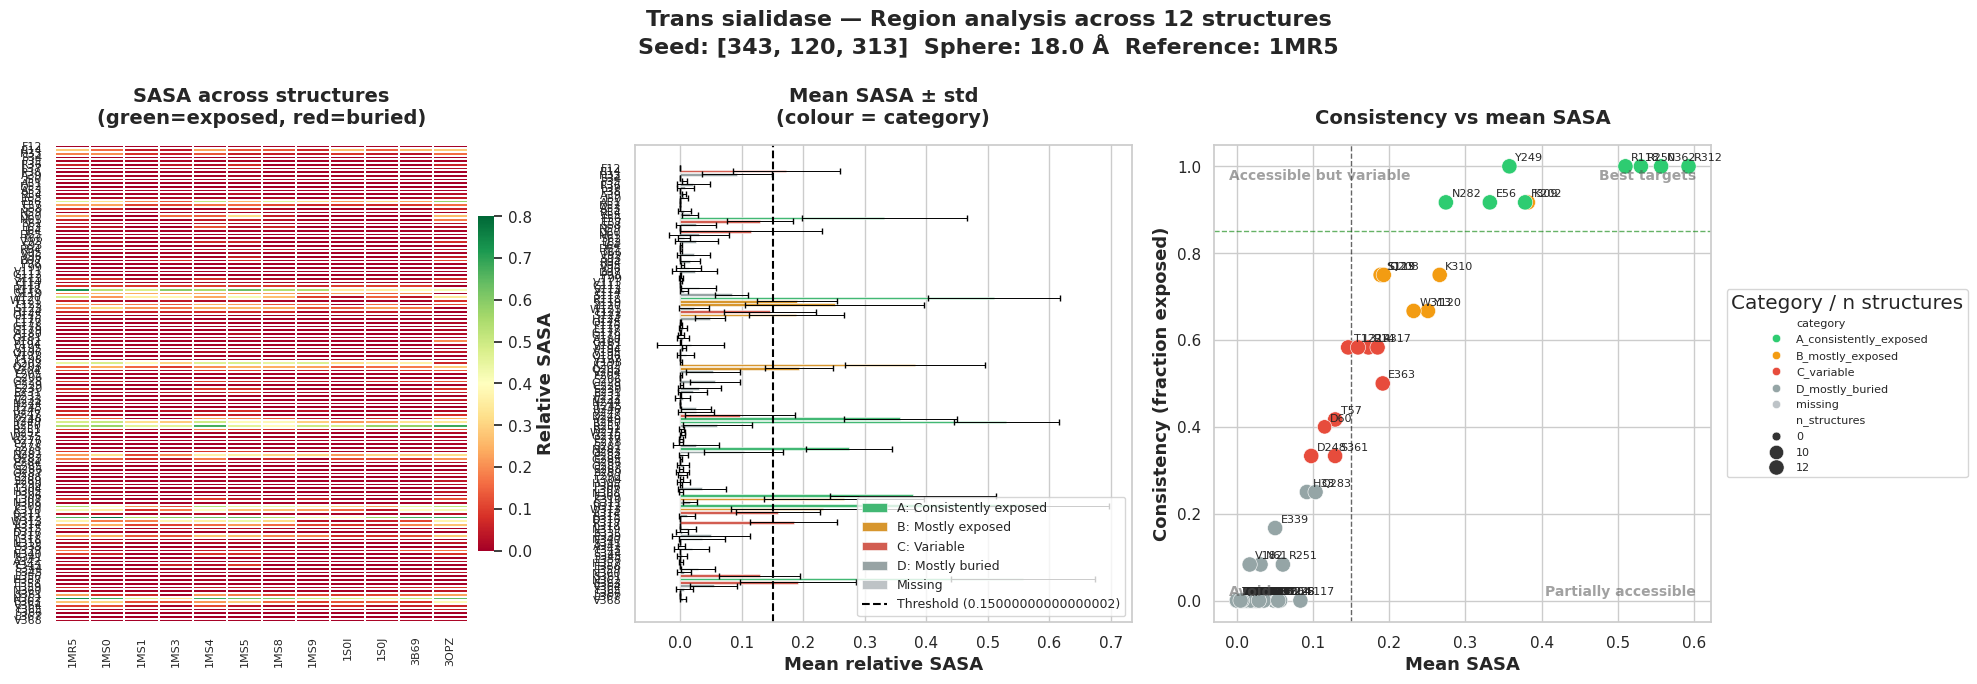

In [24]:
# Cell 11: Visualisation
# 
# Three panels:
# Left: heatmap of SASA values — structures x residues (the transition matrix)
# Centre: mean SASA bar chart for the region coloured by category
# Right: consistency vs mean SASA scatter

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

struct_names = list(structures.keys())
region_positions = sorted(region_data.keys())
residue_labels = [f"{region_data[p]['uniprot_residue']}{p}" for p in region_positions]

# Build heatmap matrix as a DataFrame (structures as columns, residues as index)
heatmap_data = np.zeros((len(region_positions), len(struct_names)))
for i, pos in enumerate(region_positions):
    for j, stem in enumerate(struct_names):
        heatmap_data[i, j] = region_data[pos]['per_structure'].get(stem, 0.0)

heatmap_data_df = pd.DataFrame(heatmap_data, index=residue_labels, columns=struct_names)

ax = axes[0]
sns.heatmap(
    heatmap_data_df,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=0.8,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Relative SASA', 'shrink': 0.7, 'pad': 0.02},
    xticklabels=True,
    yticklabels=True,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('SASA across structures\n(green=exposed, red=buried)',
             fontsize=14, fontweight='bold', pad=15)
cbar = ax.collections[0].colorbar
cbar.set_label('Relative SASA', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# Centre panel: horizontal bar chart, hue = category
bar_df = pd.DataFrame({
    'residue':    residue_labels,
    'mean_sasa':  [region_data[p]['mean_sasa'] for p in region_positions],
    'std_sasa':   [region_data[p]['std_sasa'] for p in region_positions],
    'category':   [region_data[p]['category'] for p in region_positions],
})

ax2 = axes[1]
hue_order = [c for c in CATEGORY_SASA if c in bar_df['category'].unique()]
sns.barplot(
    data=bar_df, y='residue', x='mean_sasa', hue='category',
    order=residue_labels, hue_order=hue_order, palette=CATEGORY_SASA,
    dodge=False, edgecolor='white', linewidth=0.4, ax=ax2,
)
ax2.errorbar(
    bar_df['mean_sasa'], range(len(bar_df)),
    xerr=bar_df['std_sasa'], fmt='none', color='black', capsize=2, linewidth=0.7,
)
ax2.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold ({SASA_THRESHOLD})')
ax2.set_xlabel('Mean relative SASA', fontsize=13, fontweight='bold')
ax2.set_ylabel('')
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='x', labelsize=11)
ax2.set_title('Mean SASA ± std\n(colour = category)', fontsize=14, fontweight='bold', pad=15)

category_names = {
    'A_consistently_exposed': 'A: Consistently exposed',
    'B_mostly_exposed':       'B: Mostly exposed',
    'C_variable':             'C: Variable',
    'D_mostly_buried':        'D: Mostly buried',
    'missing':                'Missing',
}
handles, labels = ax2.get_legend_handles_labels()
clean_labels = [category_names.get(l, l) for l in labels]
ax2.legend(handles, clean_labels, fontsize=9, loc='lower right')

# Right panel: consistency vs mean SASA scatter
scatter_df = pd.DataFrame({
    'residue':      residue_labels,
    'mean_sasa':    [region_data[p]['mean_sasa'] for p in region_positions],
    'consistency':  [region_data[p]['consistency'] for p in region_positions],
    'category':     [region_data[p]['category'] for p in region_positions],
    'n_structures': [region_data[p]['n_structures'] for p in region_positions],
})

ax3 = axes[2]
sns.scatterplot(
    data=scatter_df, x='mean_sasa', y='consistency',
    hue='category', hue_order=hue_order, palette=CATEGORY_SASA,
    size='n_structures', sizes=(40, 120),
    edgecolor='white', linewidth=0.4, ax=ax3, zorder=3,
)
for _, row in scatter_df.iterrows():
    ax3.annotate(row['residue'], (row['mean_sasa'], row['consistency']),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')

ax3.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax3.axhline(0.85, color='green', linestyle='--', linewidth=1, alpha=0.6)

quad_kwargs = dict(fontsize=10, fontweight='bold', alpha=0.55, color='#555555',
                    transform=ax3.transAxes)
ax3.text(0.97, 0.95, 'Best targets',              ha='right', va='top',    **quad_kwargs)
ax3.text(0.03, 0.95, 'Accessible but variable',   ha='left',  va='top',    **quad_kwargs)
ax3.text(0.97, 0.05, 'Partially accessible',      ha='right', va='bottom', **quad_kwargs)
ax3.text(0.03, 0.05, 'Avoid',                     ha='left',  va='bottom', **quad_kwargs)

ax3.set_xlabel('Mean SASA', fontsize=13, fontweight='bold')
ax3.set_ylabel('Consistency (fraction exposed)', fontsize=13, fontweight='bold')
ax3.tick_params(labelsize=11)
ax3.set_title('Consistency vs mean SASA', fontsize=14, fontweight='bold', pad=15)
ax3.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5),
           title='Category / n structures')

plt.suptitle(
    f'{TARGET_NAME} — Region analysis across {len(structures)} structures\n'
    f'Seed: {SEED_RESIDUES}  Sphere: {SPHERE_RADIUS} Å  '
    f'Reference: {REF_STRUCTURE}',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()

fig_path = output_dir / f'{TARGET_LABEL}_region_analysis.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
pass
print(f'Figure saved: {fig_path}')


In [25]:
# Cell 12: Save outputs for Notebook 01

output = {
    'target_name':          TARGET_NAME,
    'target_label':         TARGET_LABEL,
    'uniprot_accession':    UNIPROT_ACCESSION,
    'reference_structure':  REF_STRUCTURE,
    'reference_chain':      REF_CHAIN,
    'seed_residues':        SEED_RESIDUES,
    'sphere_radius':        SPHERE_RADIUS,
    'sasa_threshold':       SASA_THRESHOLD,
    'n_structures':         len(structures),
    'structures':           list(structures.keys()),
    'global_max_sasa':      global_max_sasa,
    'region_canonical':     sorted(list(region_canonical)),
    'candidate_pool_A':     candidate_pool_00a,
    'region_data':          {str(k): v for k, v in region_data.items()},
    'contact_scores':      contact_scores_dict,
}

out_path = output_dir / f'{TARGET_LABEL}_consensus_sasa.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'NOTEBOOK 00a COMPLETE — {TARGET_NAME}')
print('=' * 60)
print(f'Structures     : {list(structures.keys())}')
print(f'Region size    : {len(region_data)} residues')
print(f'Category A     : {len(cat_A)} consistently exposed')
print(f'Category B     : {len(cat_B)} mostly exposed')
print(f'Output JSON    : {out_path}')
print()
print('Category A residues (candidate pool for Notebook 01):')
print(f'  {candidate_pool_00a}')


NOTEBOOK 00a COMPLETE — Trans sialidase
Structures     : ['1MR5', '1MS0', '1MS1', '1MS3', '1MS4', '1MS5', '1MS8', '1MS9', '1S0I', '1S0J', '3B69', '3OPZ']
Region size    : 130 residues
Category A     : 8 consistently exposed
Category B     : 7 mostly exposed
Output JSON    : /mnt/c/Antibody Design/ts_consensus_sasa.json

Category A residues (candidate pool for Notebook 01):
  [56, 118, 249, 250, 282, 309, 312, 362]
